# Regression Dataset EDA



In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.features.regression_dataset import build_regression_training_dataframe


In [3]:
df=build_regression_training_dataframe()

In [4]:
df.shape

(417611, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417611 entries, 0 to 417610
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   station_id            417611 non-null  object             
 1   hour_timestamp        417611 non-null  datetime64[ns, UTC]
 2   free_bikes_current    417611 non-null  int64              
 3   empty_slots_current   417611 non-null  int64              
 4   latitude              417611 non-null  float64            
 5   longitude             417611 non-null  float64            
 6   hour_of_day           417611 non-null  int64              
 7   day_of_week           417611 non-null  int64              
 8   is_weekend            417611 non-null  bool               
 9   free_bikes_next_hour  417611 non-null  int64              
dtypes: bool(1), datetime64[ns, UTC](1), float64(2), int64(5), object(1)
memory usage: 29.1+ MB


In [6]:
df["hour_timestamp"].min(), df["hour_timestamp"].max()


(Timestamp('2026-03-01 00:00:00+0000', tz='UTC'),
 Timestamp('2026-05-08 11:00:00+0000', tz='UTC'))

In [7]:
df["station_id"].nunique(), df["hour_timestamp"].nunique()


(1515, 364)

In [8]:
all_days = pd.date_range(
    start=df["hour_timestamp"].min().floor("D"),
    end=df["hour_timestamp"].max().floor("D"),
    freq="D",
    tz="UTC",
)

observed_days = (
    df["hour_timestamp"]
    .dt.floor("D")
    .drop_duplicates()
    .sort_values()
)

missing_days = all_days.difference(observed_days)

missing_days


DatetimeIndex(['2026-03-16 00:00:00+00:00', '2026-03-17 00:00:00+00:00',
               '2026-03-18 00:00:00+00:00', '2026-03-19 00:00:00+00:00',
               '2026-03-20 00:00:00+00:00', '2026-03-21 00:00:00+00:00',
               '2026-03-22 00:00:00+00:00', '2026-03-23 00:00:00+00:00',
               '2026-03-24 00:00:00+00:00', '2026-03-25 00:00:00+00:00',
               '2026-03-26 00:00:00+00:00', '2026-03-27 00:00:00+00:00',
               '2026-03-28 00:00:00+00:00', '2026-03-29 00:00:00+00:00',
               '2026-03-30 00:00:00+00:00', '2026-03-31 00:00:00+00:00',
               '2026-04-01 00:00:00+00:00', '2026-04-02 00:00:00+00:00',
               '2026-04-03 00:00:00+00:00', '2026-04-04 00:00:00+00:00',
               '2026-04-05 00:00:00+00:00', '2026-04-06 00:00:00+00:00',
               '2026-04-07 00:00:00+00:00', '2026-04-08 00:00:00+00:00',
               '2026-04-09 00:00:00+00:00', '2026-04-10 00:00:00+00:00',
               '2026-04-11 00:00:00+00:00', '2026-0

In [9]:
len(missing_days)


47

In [10]:
daily_counts = (
    df["hour_timestamp"]
    .dt.floor("D")
    .value_counts()
    .sort_index()
)

daily_counts


hour_timestamp
2026-03-01 00:00:00+00:00    26317
2026-03-02 00:00:00+00:00    27398
2026-03-03 00:00:00+00:00    27058
2026-03-04 00:00:00+00:00    28072
2026-03-05 00:00:00+00:00    27850
2026-03-06 00:00:00+00:00    27750
2026-03-07 00:00:00+00:00    29127
2026-03-08 00:00:00+00:00    27464
2026-03-09 00:00:00+00:00    27031
2026-03-10 00:00:00+00:00    26964
2026-03-11 00:00:00+00:00    26800
2026-03-12 00:00:00+00:00    27595
2026-03-13 00:00:00+00:00    24782
2026-03-14 00:00:00+00:00    27405
2026-03-15 00:00:00+00:00    14886
2026-04-22 00:00:00+00:00     1508
2026-05-02 00:00:00+00:00     9048
2026-05-03 00:00:00+00:00     3016
2026-05-04 00:00:00+00:00     3016
2026-05-05 00:00:00+00:00     1508
2026-05-06 00:00:00+00:00     1508
2026-05-08 00:00:00+00:00     1508
Name: count, dtype: int64

In [11]:
hourly_counts = df["hour_of_day"].value_counts().sort_index()
hourly_counts


hour_of_day
0     12429
1      8973
2      6988
3      7500
4      9567
5     12896
6     17026
7     19525
8     19590
9     20929
10    21252
11    23215
12    23407
13    20321
14    19118
15    19449
16    27449
17    22973
18    21006
19    18723
20    17879
21    17310
22    15883
23    14203
Name: count, dtype: int64

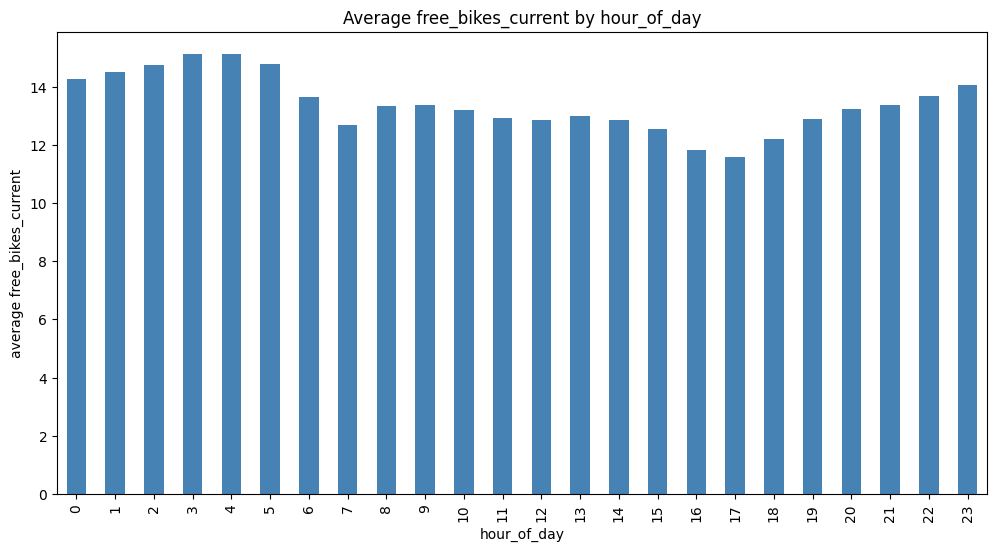

In [12]:
df.groupby("hour_of_day")["free_bikes_current"].mean().plot(
    kind="bar",
    figsize=(12, 6),
    color="steelblue"
)

plt.title("Average free_bikes_current by hour_of_day")
plt.xlabel("hour_of_day")
plt.ylabel("average free_bikes_current")
plt.show()


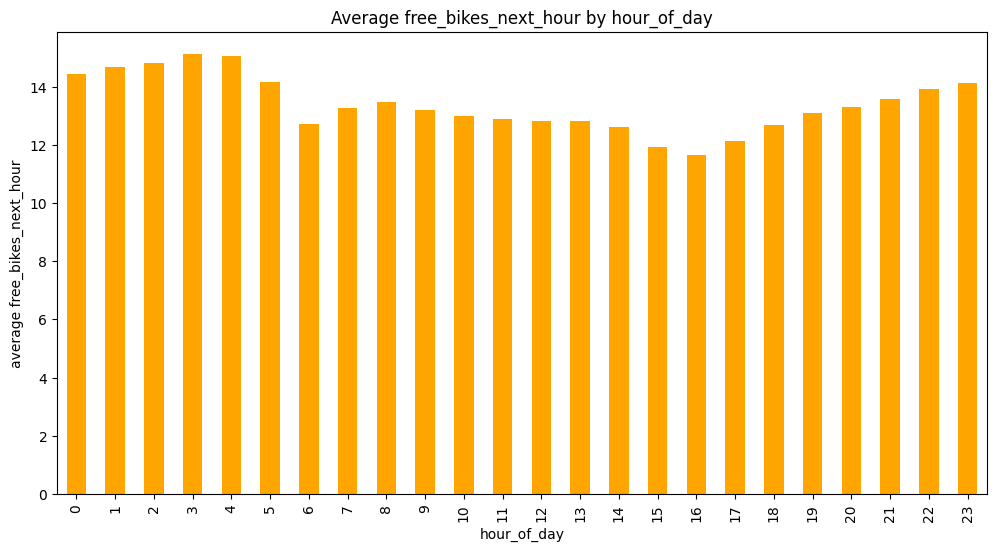

In [13]:
df.groupby("hour_of_day")["free_bikes_next_hour"].mean().plot(
    kind="bar",
    figsize=(12, 6),
    color="orange"
)

plt.title("Average free_bikes_next_hour by hour_of_day")
plt.xlabel("hour_of_day")
plt.ylabel("average free_bikes_next_hour")
plt.show()


In [14]:
df.groupby("hour_of_day")["free_bikes_current"].mean()


hour_of_day
0     14.269772
1     14.517998
2     14.746709
3     15.132533
4     15.134734
5     14.767913
6     13.660402
7     12.689885
8     13.341501
9     13.373023
10    13.203840
11    12.924532
12    12.872389
13    12.981546
14    12.852861
15    12.561880
16    11.830121
17    11.603056
18    12.204370
19    12.877103
20    13.224845
21    13.388735
22    13.676006
23    14.054777
Name: free_bikes_current, dtype: float64

In [15]:
df.groupby("hour_of_day")["free_bikes_next_hour"].mean()


hour_of_day
0     14.450157
1     14.665775
2     14.816829
3     15.131733
4     15.067942
5     14.179280
6     12.726242
7     13.270781
8     13.459571
9     13.211477
10    12.996518
11    12.880465
12    12.832358
13    12.812804
14    12.617429
15    11.921538
16    11.668877
17    12.129369
18    12.693088
19    13.096779
20    13.307120
21    13.575968
22    13.922496
23    14.141449
Name: free_bikes_next_hour, dtype: float64

free_bikes_current and free_bikes_next_hour show a similar hourly pattern, with lower availability during daytime and late afternoon, suggesting meaningful temporal structure in the prediction problem.


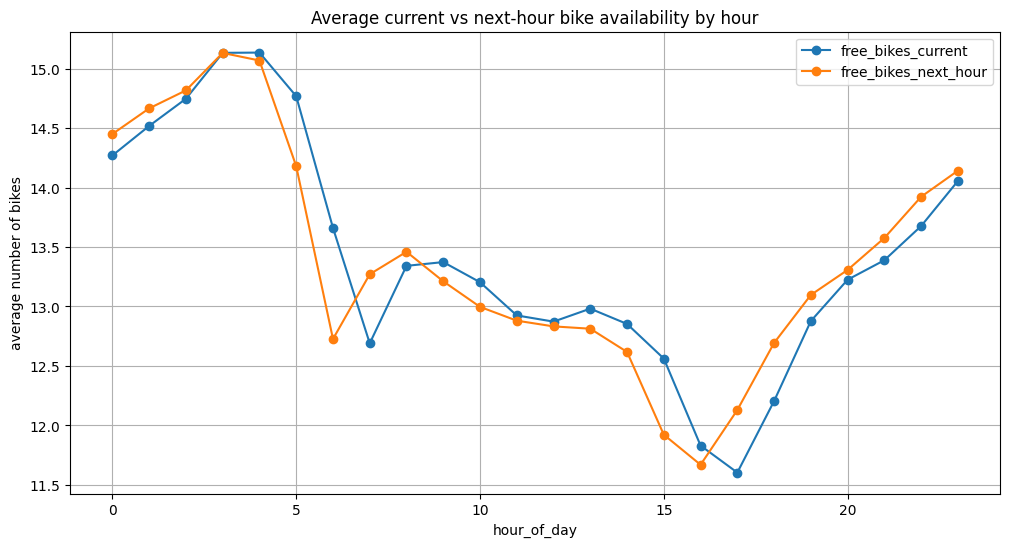

In [16]:
hourly_means = df.groupby("hour_of_day")[["free_bikes_current", "free_bikes_next_hour"]].mean()

hourly_means.plot(figsize=(12, 6), marker="o")
plt.title("Average current vs next-hour bike availability by hour")
plt.xlabel("hour_of_day")
plt.ylabel("average number of bikes")
plt.grid(True)
plt.show()


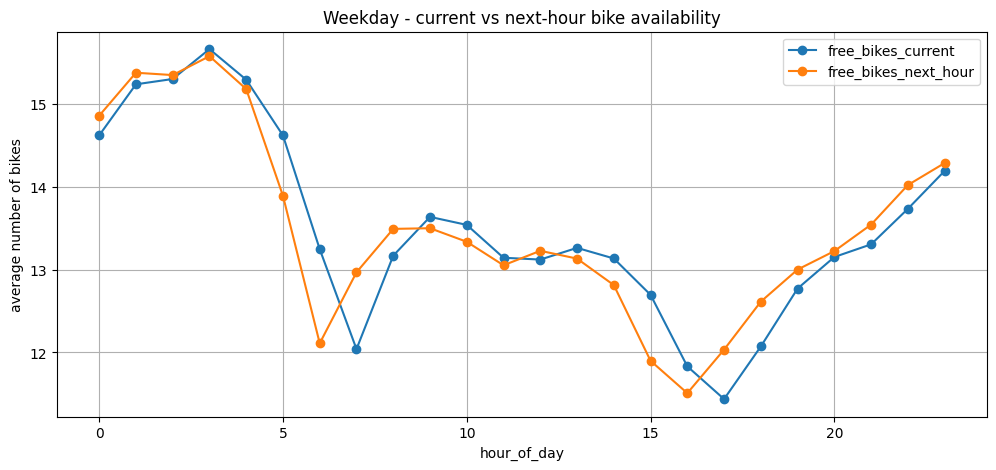

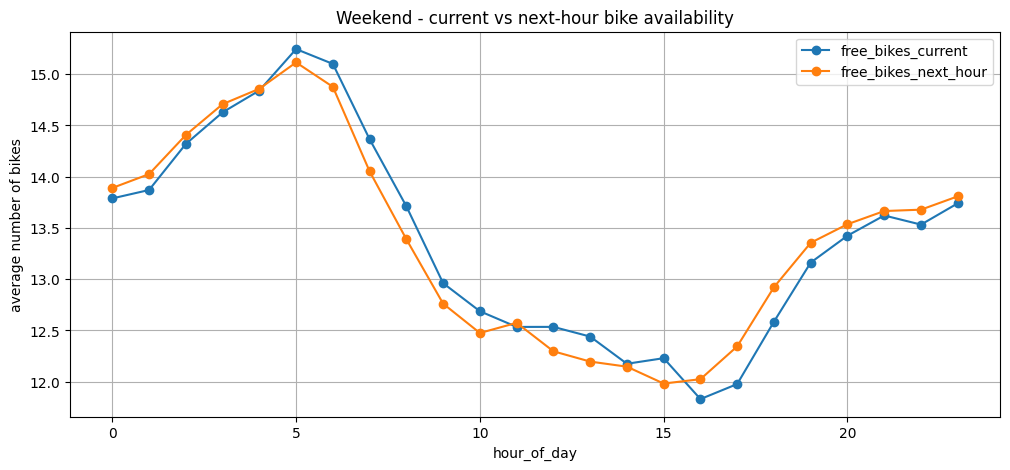

In [17]:
weekend_hourly_means = (
    df.groupby(["is_weekend", "hour_of_day"])[["free_bikes_current", "free_bikes_next_hour"]]
    .mean()
    .reset_index()
)

for is_weekend, subset in weekend_hourly_means.groupby("is_weekend"):
    label = "Weekend" if is_weekend else "Weekday"
    plt.figure(figsize=(12, 5))
    plt.plot(subset["hour_of_day"], subset["free_bikes_current"], marker="o", label="free_bikes_current")
    plt.plot(subset["hour_of_day"], subset["free_bikes_next_hour"], marker="o", label="free_bikes_next_hour")
    plt.title(f"{label} - current vs next-hour bike availability")
    plt.xlabel("hour_of_day")
    plt.ylabel("average number of bikes")
    plt.grid(True)
    plt.legend()
    plt.show()


the curve is smoother in the weekends 

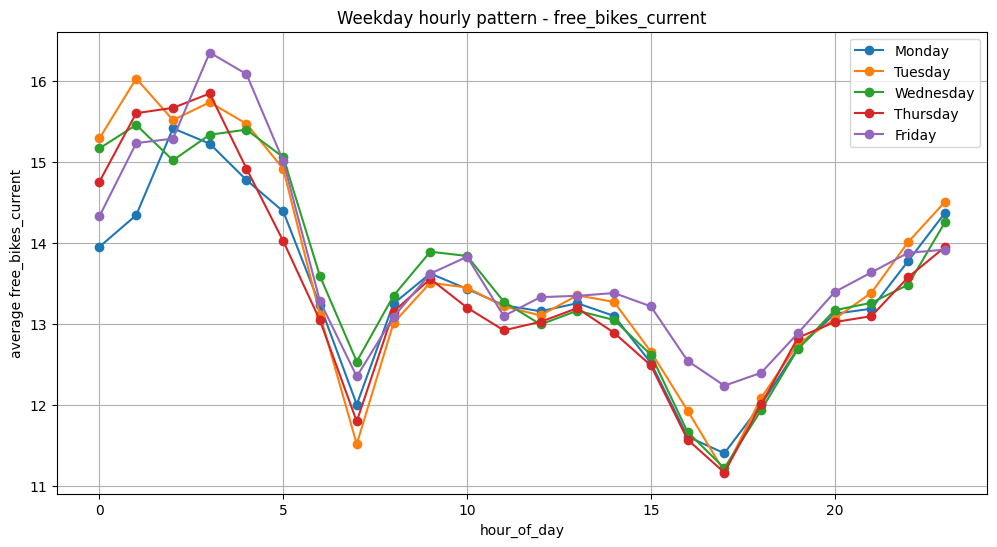

In [18]:
hourly_by_day = (
    df.groupby(["day_of_week", "hour_of_day"])["free_bikes_current"]
    .mean()
    .reset_index()
)

day_labels = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
}

plt.figure(figsize=(12, 6))

for day in [1, 2, 3, 4, 5]:
    subset = hourly_by_day[hourly_by_day["day_of_week"] == day]
    plt.plot(
        subset["hour_of_day"],
        subset["free_bikes_current"],
        marker="o",
        label=day_labels[day]
    )

plt.title("Weekday hourly pattern - free_bikes_current")
plt.xlabel("hour_of_day")
plt.ylabel("average free_bikes_current")
plt.grid(True)
plt.legend()
plt.show()


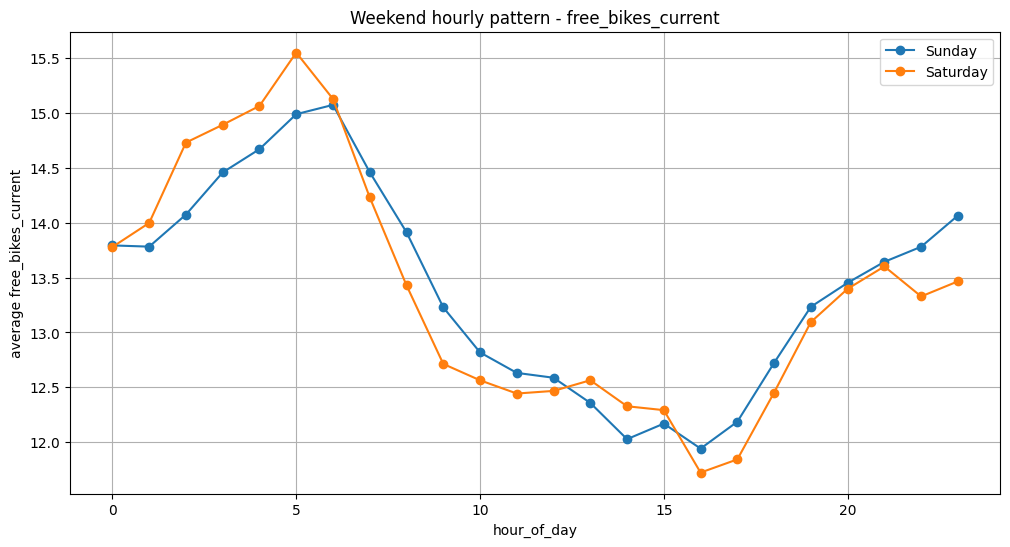

In [19]:
plt.figure(figsize=(12, 6))

for day in [0, 6]:
    subset = hourly_by_day[hourly_by_day["day_of_week"] == day]
    plt.plot(
        subset["hour_of_day"],
        subset["free_bikes_current"],
        marker="o",
        label=day_labels[day]
    )

plt.title("Weekend hourly pattern - free_bikes_current")
plt.xlabel("hour_of_day")
plt.ylabel("average free_bikes_current")
plt.grid(True)
plt.legend()
plt.show()


we can see that there's the same patterns no matter the day of the week so it's maybe a feature we can potentially delete 

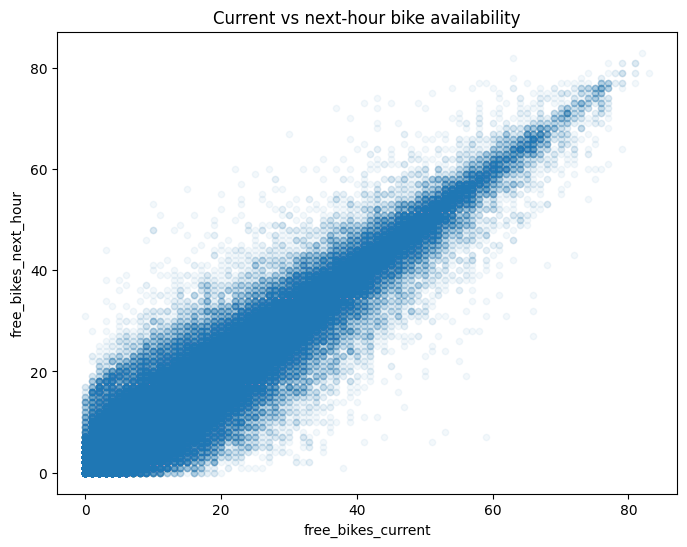

In [20]:
df.plot(
    kind="scatter",
    x="free_bikes_current",
    y="free_bikes_next_hour",
    figsize=(8, 6),
    alpha=0.05
)

plt.title("Current vs next-hour bike availability")
plt.xlabel("free_bikes_current")
plt.ylabel("free_bikes_next_hour")
plt.show()


In [21]:
df[["free_bikes_current", "free_bikes_next_hour"]].corr()


,free_bikes_current,free_bikes_next_hour
free_bikes_current,1.00000,0.95815
free_bikes_next_hour,0.95815,1.00000


In [22]:
station_counts = df["station_id"].value_counts()
station_counts.describe()


count    1515.000000
mean      275.650825
std        65.324352
min         1.000000
25%       261.000000
50%       295.000000
75%       317.000000
max       360.000000
Name: count, dtype: float64

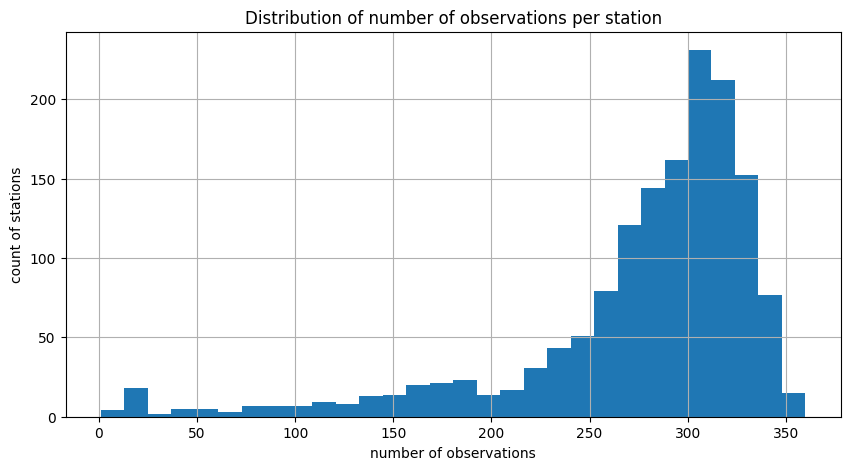

In [23]:
station_counts.hist(bins=30, figsize=(10, 5))
plt.title("Distribution of number of observations per station")
plt.xlabel("number of observations")
plt.ylabel("count of stations")
plt.show()


The station-level coverage is uneven: although most stations have a relatively high number of observations, a small subset is severely underrepresented.

In [24]:
station_mean_bikes = df.groupby("station_id")["free_bikes_current"].mean()
station_mean_bikes.describe()


count    1515.000000
mean       12.692233
std         8.534359
min         0.000000
25%         6.580308
50%        10.257235
75%        16.334110
max        64.416129
Name: free_bikes_current, dtype: float64

Average bike availability varies substantially across stations, with a right-skewed distribution and a small number of stations showing much higher average availability than the typical station.

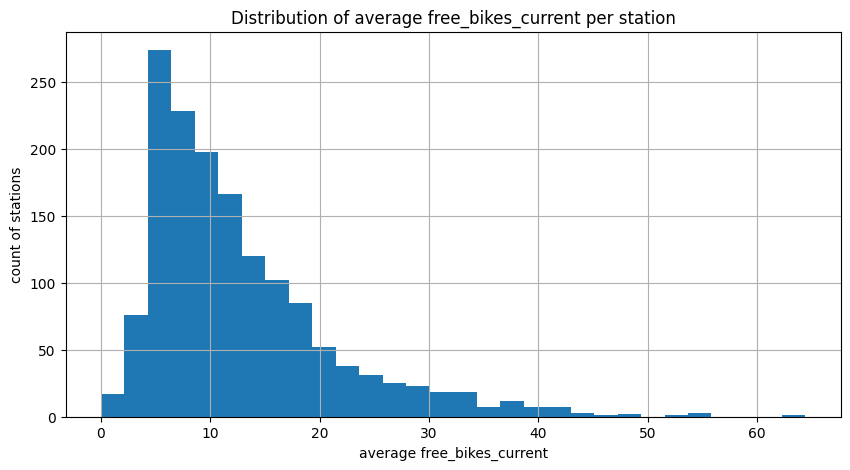

In [25]:
station_mean_bikes.hist(bins=30, figsize=(10, 5))
plt.title("Distribution of average free_bikes_current per station")
plt.xlabel("average free_bikes_current")
plt.ylabel("count of stations")
plt.show()


In [26]:
station_capacity = (
    df.assign(capacity=df["free_bikes_current"] + df["empty_slots_current"])
      .groupby("station_id")["capacity"]
      .max()
)

station_capacity.describe()
 

count    1515.000000
mean       32.339934
std        13.239635
min         0.000000
25%        23.000000
50%        30.000000
75%        38.000000
max       200.000000
Name: capacity, dtype: float64

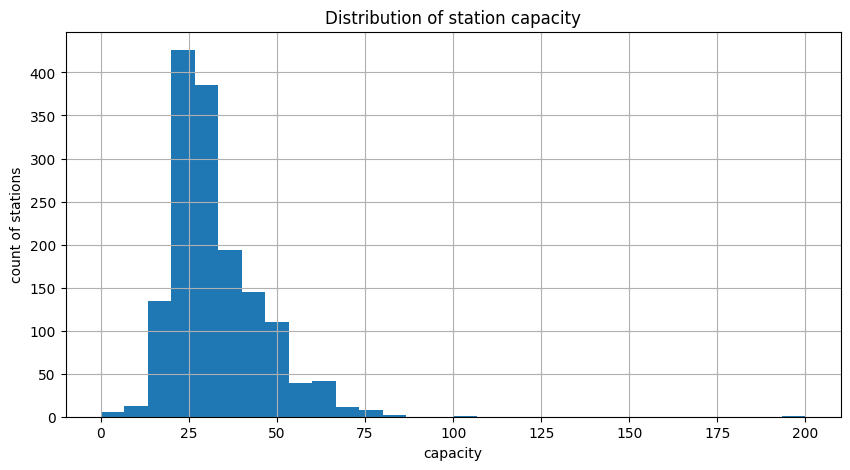

In [27]:
station_capacity.hist(bins=30, figsize=(10, 5))
plt.title("Distribution of station capacity")
plt.xlabel("capacity")
plt.ylabel("count of stations")
plt.show()


Station capacity is strongly heterogeneous and right-skewed, suggesting that raw bike counts should be interpreted in the context of station size.

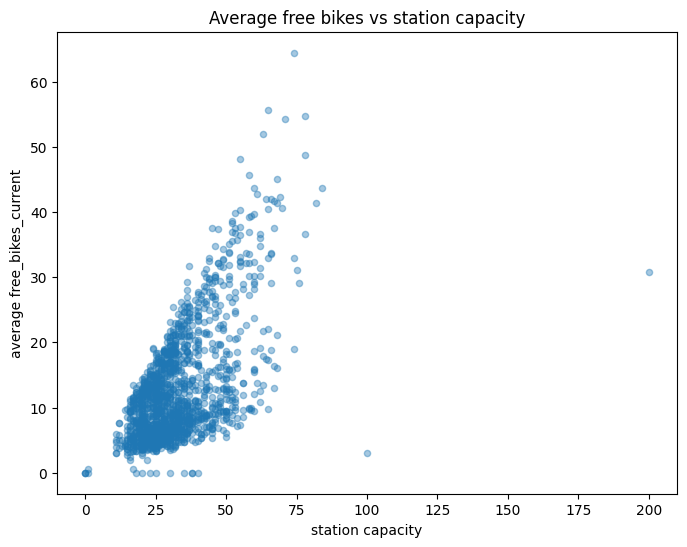

In [28]:
station_summary = (
    df.assign(capacity=df["free_bikes_current"] + df["empty_slots_current"])
      .groupby("station_id")
      .agg(
          avg_free_bikes=("free_bikes_current", "mean"),
          capacity=("capacity", "max"),
      )
)

station_summary.plot(
    kind="scatter",
    x="capacity",
    y="avg_free_bikes",
    figsize=(8, 6),
    alpha=0.4
)

plt.title("Average free bikes vs station capacity")
plt.xlabel("station capacity")
plt.ylabel("average free_bikes_current")
plt.show()


In [29]:
station_summary[["capacity", "avg_free_bikes"]].corr()


,capacity,avg_free_bikes
capacity,1.000000,0.610373
avg_free_bikes,0.610373,1.000000


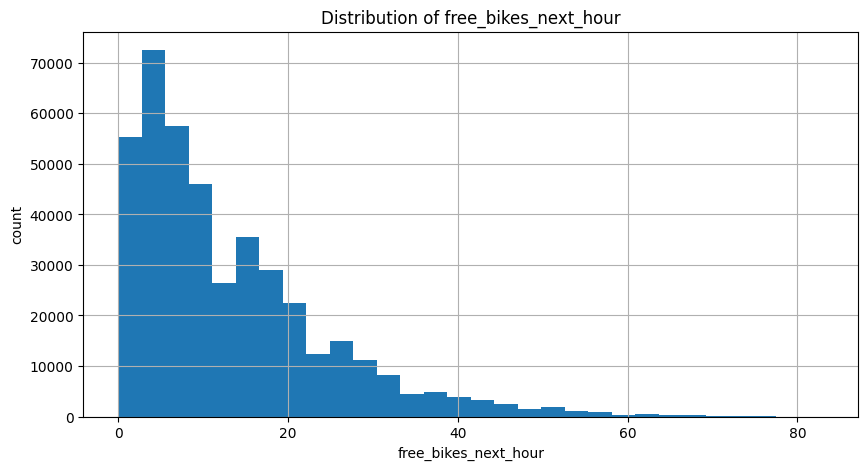

In [30]:
df["free_bikes_next_hour"].hist(bins=30, figsize=(10, 5))
plt.title("Distribution of free_bikes_next_hour")
plt.xlabel("free_bikes_next_hour")
plt.ylabel("count")
plt.show()


In [31]:
df.groupby("hour_of_day")["free_bikes_next_hour"].mean()


hour_of_day
0     14.450157
1     14.665775
2     14.816829
3     15.131733
4     15.067942
5     14.179280
6     12.726242
7     13.270781
8     13.459571
9     13.211477
10    12.996518
11    12.880465
12    12.832358
13    12.812804
14    12.617429
15    11.921538
16    11.668877
17    12.129369
18    12.693088
19    13.096779
20    13.307120
21    13.575968
22    13.922496
23    14.141449
Name: free_bikes_next_hour, dtype: float64

let's see how to do things for a few individual stations 

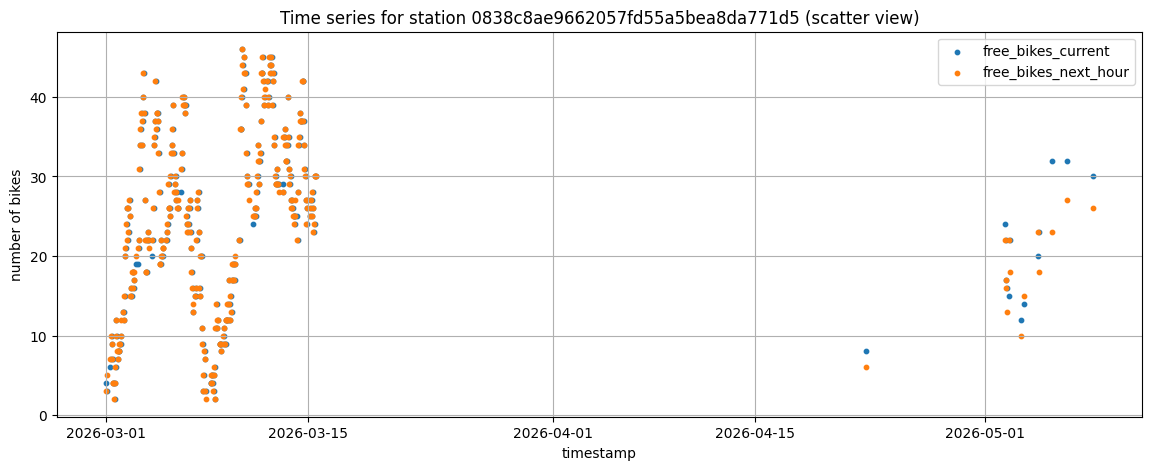

In [32]:
sample_stations = df["station_id"].drop_duplicates().sample(3, random_state=42)

sample_stations



station_id = sample_stations.iloc[0]

station_df = (
    df[df["station_id"] == station_id]
    .sort_values("hour_timestamp")
)
plt.figure(figsize=(14, 5))
plt.scatter(station_df["hour_timestamp"], station_df["free_bikes_current"], s=10, label="free_bikes_current")
plt.scatter(station_df["hour_timestamp"], station_df["free_bikes_next_hour"], s=10, label="free_bikes_next_hour")
plt.title(f"Time series for station {station_id} (scatter view)")
plt.xlabel("timestamp")
plt.ylabel("number of bikes")
plt.legend()
plt.grid(True)
plt.show()



At the individual-station level, the series are not temporally continuous across the full global date range; instead, they consist of dense local windows and sparse later observations, which confirms the irregular temporal coverage previously identified at the dataset level.

In [33]:
continuous_df = df[
    (df["hour_timestamp"] >= "2026-03-01")
    & (df["hour_timestamp"] < "2026-03-16")
].copy()

continuous_df.shape


(396499, 10)

In [34]:
continuous_days = (
    continuous_df["hour_timestamp"]
    .dt.floor("D")
    .drop_duplicates()
    .sort_values()
)

continuous_days


0     2026-03-01 00:00:00+00:00
17    2026-03-02 00:00:00+00:00
35    2026-03-03 00:00:00+00:00
52    2026-03-04 00:00:00+00:00
65    2026-03-05 00:00:00+00:00
84    2026-03-06 00:00:00+00:00
102   2026-03-07 00:00:00+00:00
117   2026-03-08 00:00:00+00:00
131   2026-03-09 00:00:00+00:00
150   2026-03-10 00:00:00+00:00
168   2026-03-11 00:00:00+00:00
185   2026-03-12 00:00:00+00:00
204   2026-03-13 00:00:00+00:00
220   2026-03-14 00:00:00+00:00
238   2026-03-15 00:00:00+00:00
Name: hour_timestamp, dtype: datetime64[ns, UTC]

In [35]:
continuous_df["station_id"].nunique(), continuous_df["hour_timestamp"].nunique()


(1512, 350)

In [36]:
station_active_days_continuous = (
    continuous_df.assign(day=continuous_df["hour_timestamp"].dt.floor("D"))
    .groupby("station_id")["day"]
    .nunique()
)

station_active_days_continuous.describe()


count    1512.000000
mean       14.769841
std         1.606552
min         1.000000
25%        15.000000
50%        15.000000
75%        15.000000
max        15.000000
Name: day, dtype: float64

In [37]:
working_df = continuous_df.copy()
working_df.shape


(396499, 10)

## Summary

- The full dataset is not temporally continuous, with many missing days between March 1 and May 6, 2026.
- Most of the useful data is concentrated in a dense and coherent block from March 1 to March 15, 2026.
- Keeping only this March block preserves most observations while greatly improving temporal consistency.
- The filtered subset still has strong coverage, with 1512 stations and 350 distinct hourly timestamps.
- Station-level continuity is also strong in this subset, since most stations are observed on all 15 days.
- Bike availability shows a clear hourly pattern, with lower values during daytime and late afternoon.
- Weekend patterns are smoother than weekday patterns, which suggests that `is_weekend` is a meaningful feature.
- `day_of_week` appears to add limited signal beyond the broader weekday/weekend distinction.
- `free_bikes_current` is very strongly related to `free_bikes_next_hour`, confirming a strong autoregressive structure.
- Station-level average availability and station capacity are both highly heterogeneous and right-skewed.
- Capacity explains part of the cross-station variability, but not all of it.

## Decision

- Use the continuous March subset as the main working dataset.
- Start with `free_bikes_current`, `empty_slots_current`, `hour_of_day`, and `is_weekend` as core features.
- Treat `day_of_week` as optional and validate its usefulness later.


In [38]:
feature_columns = [
    "free_bikes_current",
    "empty_slots_current",
    "hour_of_day",
    "is_weekend",
]

target_column = "free_bikes_next_hour"

X = working_df[feature_columns]
y = working_df[target_column]

X.shape, y.shape


((396499, 4), (396499,))

In [39]:
train_end = pd.Timestamp("2026-03-11 00:00:00", tz="UTC")
val_end = pd.Timestamp("2026-03-13 00:00:00", tz="UTC")

train_df = working_df[working_df["hour_timestamp"] < train_end]
val_df = working_df[
    (working_df["hour_timestamp"] >= train_end)
    & (working_df["hour_timestamp"] < val_end)
]
test_df = working_df[working_df["hour_timestamp"] >= val_end]

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_val = val_df[feature_columns]
y_val = val_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]


In [40]:
print(train_df["hour_timestamp"].min(), train_df["hour_timestamp"].max())
print(val_df["hour_timestamp"].min(), val_df["hour_timestamp"].max())
print(test_df["hour_timestamp"].min(), test_df["hour_timestamp"].max())

print(X_train.shape, X_val.shape, X_test.shape)


2026-03-01 00:00:00+00:00 2026-03-10 23:00:00+00:00
2026-03-11 00:00:00+00:00 2026-03-12 23:00:00+00:00
2026-03-13 00:00:00+00:00 2026-03-15 13:00:00+00:00
(275031, 4) (54395, 4) (67073, 4)


In [41]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri(f"file://{project_root / 'mlruns'}")

mlflow.set_experiment("velib-demand-forecasting")



/Users/zakariaouahabi/Documents/velib-demand-forecasting/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///Users/zakariaouahabi/Documents/velib-demand-forecasting/mlruns/816218909226413421', creation_time=1778422771964, experiment_id='816218909226413421', last_update_time=1778422771964, lifecycle_stage='active', name='velib-demand-forecasting', tags={}, trace_location=None, workspace='default'>

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_model = LinearRegression()

with mlflow.start_run(run_name="linear_regression_baseline"):
    baseline_model.fit(X_train, y_train)

    val_predictions = baseline_model.predict(X_val)

    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_r2 = r2_score(y_val, val_predictions)

    mlflow.log_param("model_name", "LinearRegression")
    mlflow.log_param("features", feature_columns)

    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.sklearn.log_model(baseline_model, "model")

    print("Validation RMSE:", val_rmse)
    print("Validation MAE:", val_mae)
    print("Validation R2:", val_r2)


2026/05/13 23:05:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 23:05:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Validation RMSE: 3.319324154262461
Validation MAE: 2.2716873094376084
Validation R2: 0.9141108490231235


In [43]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)

with mlflow.start_run(run_name="random_forest_baseline"):
    rf_model.fit(X_train, y_train)

    val_predictions = rf_model.predict(X_val)

    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_r2 = r2_score(y_val, val_predictions)

    mlflow.log_param("model_name", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("features", feature_columns)

    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.sklearn.log_model(rf_model, "model")

    print("Validation RMSE:", val_rmse)
    print("Validation MAE:", val_mae)
    print("Validation R2:", val_r2)


2026/05/13 23:05:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 23:05:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Validation RMSE: 3.583805772755006
Validation MAE: 2.469631418018622
Validation R2: 0.8998783711059934


In [44]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42,
)

with mlflow.start_run(run_name="gradient_boosting_baseline"):
    gb_model.fit(X_train, y_train)

    val_predictions = gb_model.predict(X_val)

    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_r2 = r2_score(y_val, val_predictions)

    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("features", feature_columns)

    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.sklearn.log_model(gb_model, "model")

    print("Validation RMSE:", val_rmse)
    print("Validation MAE:", val_mae)
    print("Validation R2:", val_r2)


2026/05/13 23:05:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 23:05:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Validation RMSE: 3.263255919914943
Validation MAE: 2.240225421052631
Validation R2: 0.9169879294860603


In [45]:
with mlflow.start_run(run_name="naive_baseline_current_equals_next"):
    val_predictions = X_val["free_bikes_current"]

    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_r2 = r2_score(y_val, val_predictions)

    mlflow.log_param("model_name", "NaiveBaseline")
    mlflow.log_param("rule", "predict free_bikes_next_hour = free_bikes_current")
    mlflow.log_param("features", ["free_bikes_current"])

    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_r2", val_r2)

    print("Validation RMSE:", val_rmse)
    print("Validation MAE:", val_mae)
    print("Validation R2:", val_r2)


Validation RMSE: 3.360946994916479
Validation MAE: 2.2411986395808436
Validation R2: 0.911943320684309


The GradientBoostingRegressor achieves the best validation performance so far, but the naïve baseline remains highly competitive, confirming that the forecasting problem is strongly driven by the current bike availability level.

In [46]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
)

with mlflow.start_run(run_name="gbr_tuned_1"):
    gb_model.fit(X_train, y_train)

    val_predictions = gb_model.predict(X_val)

    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    val_mae = mean_absolute_error(y_val, val_predictions)
    val_r2 = r2_score(y_val, val_predictions)

    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 3)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("features", feature_columns)

    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.sklearn.log_model(gb_model, "model")

    print("Validation RMSE:", val_rmse)
    print("Validation MAE:", val_mae)
    print("Validation R2:", val_r2)


2026/05/13 23:06:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 23:06:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Validation RMSE: 3.2626208071393434
Validation MAE: 2.239285832095307
Validation R2: 0.9170202388710924


In [47]:
from sklearn.model_selection import TimeSeriesSplit

dev_df = pd.concat([train_df, val_df]).sort_values("hour_timestamp").reset_index(drop=True)
X_dev = dev_df[feature_columns]
y_dev = dev_df[target_column]

tscv = TimeSeriesSplit(n_splits=3)


In [48]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


fold_rmse = []
fold_mae = []
fold_r2 = []

with mlflow.start_run(run_name="gbr_timeseries_cv"):
    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("cv_type", "TimeSeriesSplit")
    mlflow.log_param("n_splits", 3)
    mlflow.log_param("features", feature_columns)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), start=1):
        X_fold_train = X_dev.iloc[train_idx]
        y_fold_train = y_dev.iloc[train_idx]

        X_fold_val = X_dev.iloc[val_idx]
        y_fold_val = y_dev.iloc[val_idx]

        model = GradientBoostingRegressor(
            n_estimators=100,
            random_state=42,
        )

        model.fit(X_fold_train, y_fold_train)
        val_predictions = model.predict(X_fold_val)

        rmse = np.sqrt(mean_squared_error(y_fold_val, val_predictions))
        mae = mean_absolute_error(y_fold_val, val_predictions)
        r2 = r2_score(y_fold_val, val_predictions)

        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)

        mlflow.log_metric(f"fold_{fold}_rmse", rmse)
        mlflow.log_metric(f"fold_{fold}_mae", mae)
        mlflow.log_metric(f"fold_{fold}_r2", r2)

        print(f"Fold {fold} RMSE: {rmse:.4f}")
        print(f"Fold {fold} MAE: {mae:.4f}")
        print(f"Fold {fold} R2: {r2:.4f}")
        print()

    mlflow.log_metric("cv_rmse_mean", np.mean(fold_rmse))
    mlflow.log_metric("cv_mae_mean", np.mean(fold_mae))
    mlflow.log_metric("cv_r2_mean", np.mean(fold_r2))

    print("Mean CV RMSE:", np.mean(fold_rmse))
    print("Mean CV MAE:", np.mean(fold_mae))
    print("Mean CV R2:", np.mean(fold_r2))


Fold 1 RMSE: 3.3704
Fold 1 MAE: 2.2853
Fold 1 R2: 0.9190

Fold 2 RMSE: 3.2011
Fold 2 MAE: 2.1791
Fold 2 R2: 0.9162

Fold 3 RMSE: 3.3758
Fold 3 MAE: 2.2835
Fold 3 R2: 0.9129

Mean CV RMSE: 3.315768509408187
Mean CV MAE: 2.249302351364811
Mean CV R2: 0.9160094234751638


In [49]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

param_grid = [
    {
        "n_estimators": 100,
        "learning_rate": 0.1,
        "max_depth": 3,
        "min_samples_leaf": 1,
        "subsample": 1.0,
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_samples_leaf": 1,
        "subsample": 1.0,
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_samples_leaf": 1,
        "subsample": 1.0,
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 5,
        "subsample": 1.0,
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_samples_leaf": 5,
        "subsample": 0.8,
    },
]

cv_results = []

for run_idx, params in enumerate(param_grid, start=1):
    fold_rmse = []
    fold_mae = []
    fold_r2 = []

    with mlflow.start_run(run_name=f"gbr_cv_tuning_run_{run_idx}"):
        mlflow.log_param("model_name", "GradientBoostingRegressor")
        mlflow.log_param("cv_type", "TimeSeriesSplit")
        mlflow.log_param("n_splits", 3)
        mlflow.log_param("features", feature_columns)

        for key, value in params.items():
            mlflow.log_param(key, value)

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), start=1):
            X_fold_train = X_dev.iloc[train_idx]
            y_fold_train = y_dev.iloc[train_idx]

            X_fold_val = X_dev.iloc[val_idx]
            y_fold_val = y_dev.iloc[val_idx]

            model = GradientBoostingRegressor(
                n_estimators=params["n_estimators"],
                learning_rate=params["learning_rate"],
                max_depth=params["max_depth"],
                min_samples_leaf=params["min_samples_leaf"],
                subsample=params["subsample"],
                random_state=42,
            )

            model.fit(X_fold_train, y_fold_train)
            val_predictions = model.predict(X_fold_val)

            rmse = np.sqrt(mean_squared_error(y_fold_val, val_predictions))
            mae = mean_absolute_error(y_fold_val, val_predictions)
            r2 = r2_score(y_fold_val, val_predictions)

            fold_rmse.append(rmse)
            fold_mae.append(mae)
            fold_r2.append(r2)

            mlflow.log_metric(f"fold_{fold}_rmse", rmse)
            mlflow.log_metric(f"fold_{fold}_mae", mae)
            mlflow.log_metric(f"fold_{fold}_r2", r2)

        cv_rmse_mean = np.mean(fold_rmse)
        cv_mae_mean = np.mean(fold_mae)
        cv_r2_mean = np.mean(fold_r2)

        mlflow.log_metric("cv_rmse_mean", cv_rmse_mean)
        mlflow.log_metric("cv_mae_mean", cv_mae_mean)
        mlflow.log_metric("cv_r2_mean", cv_r2_mean)

        cv_results.append(
            {
                "run_idx": run_idx,
                **params,
                "cv_rmse_mean": cv_rmse_mean,
                "cv_mae_mean": cv_mae_mean,
                "cv_r2_mean": cv_r2_mean,
            }
        )

results_df = pd.DataFrame(cv_results).sort_values("cv_rmse_mean")
results_df


,run_idx,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample,cv_rmse_mean,cv_mae_mean,cv_r2_mean
4,5,200,0.05,3,5,0.8,3.314751,2.248981,0.916060
0,1,100,0.10,3,1,1.0,3.315769,2.249302,0.916009
1,2,200,0.05,3,1,1.0,3.315783,2.249315,0.916007
2,3,300,0.03,3,1,1.0,3.319531,2.250495,0.915820
3,4,200,0.05,2,5,1.0,3.342103,2.263787,0.914676


How will the model perform after adding a. new feature Adding a new feature 

In [50]:
working_df_v2 = continuous_df.copy()

working_df_v2["capacity"] = (
    working_df_v2["free_bikes_current"] + working_df_v2["empty_slots_current"]
)

working_df_v2.shape


(396499, 11)

In [51]:
feature_columns_v2 = [
    "free_bikes_current",
    "empty_slots_current",
    "hour_of_day",
    "is_weekend",
    "capacity",
]

target_column = "free_bikes_next_hour"
train_end = pd.Timestamp("2026-03-11 00:00:00", tz="UTC")
val_end = pd.Timestamp("2026-03-13 00:00:00", tz="UTC")

train_df_v2 = working_df_v2[working_df_v2["hour_timestamp"] < train_end]
val_df_v2 = working_df_v2[
    (working_df_v2["hour_timestamp"] >= train_end)
    & (working_df_v2["hour_timestamp"] < val_end)
]
test_df_v2 = working_df_v2[working_df_v2["hour_timestamp"] >= val_end]

X_train_v2 = train_df_v2[feature_columns_v2]
y_train_v2 = train_df_v2[target_column]

X_val_v2 = val_df_v2[feature_columns_v2]
y_val_v2 = val_df_v2[target_column]

X_test_v2 = test_df_v2[feature_columns_v2]
y_test_v2 = test_df_v2[target_column]

print(X_train_v2.shape, X_val_v2.shape, X_test_v2.shape)



(275031, 5) (54395, 5) (67073, 5)


In [52]:
dev_df_v2 = (
    pd.concat([train_df_v2, val_df_v2])
    .sort_values("hour_timestamp")
    .reset_index(drop=True)
)

X_dev_v2 = dev_df_v2[feature_columns_v2]
y_dev_v2 = dev_df_v2[target_column]

X_dev_v2.shape


(329426, 5)

In [53]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=3)

best_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_samples_leaf": 5,
    "subsample": 0.8,
    "random_state": 42,
}

fold_rmse = []
fold_mae = []
fold_r2 = []

with mlflow.start_run(run_name="gbr_cv_capacity_v2"):
    mlflow.log_param("dataset_version", "working_df_v2")
    mlflow.log_param("feature_set_name", "core_plus_capacity")
    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("cv_type", "TimeSeriesSplit")
    mlflow.log_param("n_splits", 3)
    mlflow.log_param("features", feature_columns_v2)

    for key, value in best_params.items():
        mlflow.log_param(key, value)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev_v2), start=1):
        X_fold_train = X_dev_v2.iloc[train_idx]
        y_fold_train = y_dev_v2.iloc[train_idx]

        X_fold_val = X_dev_v2.iloc[val_idx]
        y_fold_val = y_dev_v2.iloc[val_idx]

        model = GradientBoostingRegressor(**best_params)
        model.fit(X_fold_train, y_fold_train)

        val_predictions = model.predict(X_fold_val)

        rmse = np.sqrt(mean_squared_error(y_fold_val, val_predictions))
        mae = mean_absolute_error(y_fold_val, val_predictions)
        r2 = r2_score(y_fold_val, val_predictions)

        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)

        mlflow.log_metric(f"fold_{fold}_rmse", rmse)
        mlflow.log_metric(f"fold_{fold}_mae", mae)
        mlflow.log_metric(f"fold_{fold}_r2", r2)

    mlflow.log_metric("cv_rmse_mean", np.mean(fold_rmse))
    mlflow.log_metric("cv_mae_mean", np.mean(fold_mae))
    mlflow.log_metric("cv_r2_mean", np.mean(fold_r2))

    print("Mean CV RMSE:", np.mean(fold_rmse))
    print("Mean CV MAE:", np.mean(fold_mae))
    print("Mean CV R2:", np.mean(fold_r2))


Mean CV RMSE: 3.3125283241025305
Mean CV MAE: 2.249047349208105
Mean CV R2: 0.9161715296739015


The new run is marginally better on MAE and R², while the old run is marginally better on rmse. However, all differences are extremely small, so the two configurations should be considered practically equivalent.


In [56]:
feature_columns_v3 = [
    "free_bikes_current",
    "empty_slots_current",
    "hour_of_day",
    "is_weekend",
    "latitude",
    "longitude",
]

target_column = "free_bikes_next_hour"


In [57]:
working_df_v3 = continuous_df.copy()
working_df_v3.shape


(396499, 10)

In [58]:
train_end = pd.Timestamp("2026-03-11 00:00:00", tz="UTC")
val_end = pd.Timestamp("2026-03-13 00:00:00", tz="UTC")

train_df_v3 = working_df_v3[working_df_v3["hour_timestamp"] < train_end]
val_df_v3 = working_df_v3[
    (working_df_v3["hour_timestamp"] >= train_end)
    & (working_df_v3["hour_timestamp"] < val_end)
]
test_df_v3 = working_df_v3[working_df_v3["hour_timestamp"] >= val_end]

X_train_v3 = train_df_v3[feature_columns_v3]
y_train_v3 = train_df_v3[target_column]

X_val_v3 = val_df_v3[feature_columns_v3]
y_val_v3 = val_df_v3[target_column]

X_test_v3 = test_df_v3[feature_columns_v3]
y_test_v3 = test_df_v3[target_column]

print(X_train_v3.shape, X_val_v3.shape, X_test_v3.shape)


(275031, 6) (54395, 6) (67073, 6)


In [59]:
dev_df_v3 = (
    pd.concat([train_df_v3, val_df_v3])
    .sort_values("hour_timestamp")
    .reset_index(drop=True)
)

X_dev_v3 = dev_df_v3[feature_columns_v3]
y_dev_v3 = dev_df_v3[target_column]

X_dev_v3.shape


(329426, 6)

In [60]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=3)

best_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_samples_leaf": 5,
    "subsample": 0.8,
    "random_state": 42,
}

fold_rmse = []
fold_mae = []
fold_r2 = []

with mlflow.start_run(run_name="gbr_cv_lat_lon_v3"):
    mlflow.log_param("dataset_version", "working_df_v3")
    mlflow.log_param("feature_set_name", "core_plus_lat_lon")
    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("cv_type", "TimeSeriesSplit")
    mlflow.log_param("n_splits", 3)
    mlflow.log_param("features", feature_columns_v3)

    for key, value in best_params.items():
        mlflow.log_param(key, value)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev_v3), start=1):
        X_fold_train = X_dev_v3.iloc[train_idx]
        y_fold_train = y_dev_v3.iloc[train_idx]

        X_fold_val = X_dev_v3.iloc[val_idx]
        y_fold_val = y_dev_v3.iloc[val_idx]

        model = GradientBoostingRegressor(**best_params)
        model.fit(X_fold_train, y_fold_train)

        val_predictions = model.predict(X_fold_val)

        rmse = np.sqrt(mean_squared_error(y_fold_val, val_predictions))
        mae = mean_absolute_error(y_fold_val, val_predictions)
        r2 = r2_score(y_fold_val, val_predictions)

        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)

        mlflow.log_metric(f"fold_{fold}_rmse", rmse)
        mlflow.log_metric(f"fold_{fold}_mae", mae)
        mlflow.log_metric(f"fold_{fold}_r2", r2)

    mlflow.log_metric("cv_rmse_mean", np.mean(fold_rmse))
    mlflow.log_metric("cv_mae_mean", np.mean(fold_mae))
    mlflow.log_metric("cv_r2_mean", np.mean(fold_r2))

    print("Mean CV RMSE:", np.mean(fold_rmse))
    print("Mean CV MAE:", np.mean(fold_mae))
    print("Mean CV R2:", np.mean(fold_r2))


Mean CV RMSE: 3.296507049593368
Mean CV MAE: 2.233321350074512
Mean CV R2: 0.9169813986536844


Adding latitude and longitude yields a clearer improvement than adding capacity, suggesting that spatial location captures meaningful station-level heterogeneity that is not sufficiently explained by station size alone.



In [61]:
working_df_v4 = continuous_df.copy()

working_df_v4 = working_df_v4.sort_values(["station_id", "hour_timestamp"]).reset_index(drop=True)

working_df_v4["free_bikes_t_minus_1"] = (
    working_df_v4.groupby("station_id")["free_bikes_current"].shift(1)
)

working_df_v4["free_bikes_t_minus_2"] = (
    working_df_v4.groupby("station_id")["free_bikes_current"].shift(2)
)

working_df_v4["free_bikes_t_minus_3"] = (
    working_df_v4.groupby("station_id")["free_bikes_current"].shift(3)
)

working_df_v4["delta_1h"] = (
    working_df_v4["free_bikes_current"] - working_df_v4["free_bikes_t_minus_1"]
)

working_df_v4["delta_3h"] = (
    working_df_v4["free_bikes_current"] - working_df_v4["free_bikes_t_minus_3"]
)


In [62]:
working_df_v4[
    [
        "free_bikes_t_minus_1",
        "free_bikes_t_minus_2",
        "free_bikes_t_minus_3",
        "delta_1h",
        "delta_3h",
    ]
].isna().sum()


free_bikes_t_minus_1    1512
free_bikes_t_minus_2    3008
free_bikes_t_minus_3    4503
delta_1h                1512
delta_3h                4503
dtype: int64

In [65]:
working_df_v4_lagged = working_df_v4.dropna(
    subset=[
        "free_bikes_t_minus_1",
        "free_bikes_t_minus_2",
        "free_bikes_t_minus_3",
        "delta_1h",
        "delta_3h",
    ]
).copy()

print("Original shape:", working_df_v4.shape)
print("Lagged shape:", working_df_v4_lagged.shape)
print("Rows dropped:", len(working_df_v4) - len(working_df_v4_lagged))


Original shape: (396499, 15)
Lagged shape: (391996, 15)
Rows dropped: 4503


In [67]:
feature_columns_v4 = [
    "free_bikes_current",
    "empty_slots_current",
    "hour_of_day",
    "is_weekend",
    "latitude",
    "longitude",
    "free_bikes_t_minus_1",
    "free_bikes_t_minus_2",
    "free_bikes_t_minus_3",
    "delta_1h",
    "delta_3h",
]

target_column = "free_bikes_next_hour"


In [68]:
train_end = pd.Timestamp("2026-03-11 00:00:00", tz="UTC")
val_end = pd.Timestamp("2026-03-13 00:00:00", tz="UTC")

train_df_v4 = working_df_v4_lagged[working_df_v4_lagged["hour_timestamp"] < train_end]
val_df_v4 = working_df_v4_lagged[
    (working_df_v4_lagged["hour_timestamp"] >= train_end)
    & (working_df_v4_lagged["hour_timestamp"] < val_end)
]
test_df_v4 = working_df_v4_lagged[working_df_v4_lagged["hour_timestamp"] >= val_end]

X_train_v4 = train_df_v4[feature_columns_v4]
y_train_v4 = train_df_v4[target_column]

X_val_v4 = val_df_v4[feature_columns_v4]
y_val_v4 = val_df_v4[target_column]

X_test_v4 = test_df_v4[feature_columns_v4]
y_test_v4 = test_df_v4[target_column]

print(X_train_v4.shape, X_val_v4.shape, X_test_v4.shape)


(270529, 11) (54395, 11) (67072, 11)


In [69]:
dev_df_v4 = (
    pd.concat([train_df_v4, val_df_v4])
    .sort_values("hour_timestamp")
    .reset_index(drop=True)
)

X_dev_v4 = dev_df_v4[feature_columns_v4]
y_dev_v4 = dev_df_v4[target_column]

X_dev_v4.shape


(324924, 11)

In [70]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=3)

best_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_samples_leaf": 5,
    "subsample": 0.8,
    "random_state": 42,
}

fold_rmse = []
fold_mae = []
fold_r2 = []

with mlflow.start_run(run_name="gbr_cv_lat_lon_lags_v4"):
    mlflow.log_param("dataset_version", "working_df_v4_lagged")
    mlflow.log_param("feature_set_name", "core_plus_lat_lon_plus_lags")
    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("cv_type", "TimeSeriesSplit")
    mlflow.log_param("n_splits", 3)
    mlflow.log_param("features", feature_columns_v4)

    for key, value in best_params.items():
        mlflow.log_param(key, value)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev_v4), start=1):
        X_fold_train = X_dev_v4.iloc[train_idx]
        y_fold_train = y_dev_v4.iloc[train_idx]

        X_fold_val = X_dev_v4.iloc[val_idx]
        y_fold_val = y_dev_v4.iloc[val_idx]

        model = GradientBoostingRegressor(**best_params)
        model.fit(X_fold_train, y_fold_train)

        val_predictions = model.predict(X_fold_val)

        rmse = np.sqrt(mean_squared_error(y_fold_val, val_predictions))
        mae = mean_absolute_error(y_fold_val, val_predictions)
        r2 = r2_score(y_fold_val, val_predictions)

        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)

        mlflow.log_metric(f"fold_{fold}_rmse", rmse)
        mlflow.log_metric(f"fold_{fold}_mae", mae)
        mlflow.log_metric(f"fold_{fold}_r2", r2)

    mlflow.log_metric("cv_rmse_mean", np.mean(fold_rmse))
    mlflow.log_metric("cv_mae_mean", np.mean(fold_mae))
    mlflow.log_metric("cv_r2_mean", np.mean(fold_r2))

    print("Mean CV RMSE:", np.mean(fold_rmse))
    print("Mean CV MAE:", np.mean(fold_mae))
    print("Mean CV R2:", np.mean(fold_r2))


Mean CV RMSE: 3.201564641807248
Mean CV MAE: 2.2052304670878975
Mean CV R2: 0.9217430944053028


Adding lag and delta features leads to a clear improvement across all cross-validated metrics, indicating that short-term temporal dynamics provide substantial predictive information beyond the current state, calendar features, and spatial coordinates.



In [71]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

best_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_samples_leaf": 5,
    "subsample": 0.8,
    "random_state": 42,
}

feature_set_validation_results = []

feature_sets = [
    {
        "feature_set_name": "core",
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
    },
    {
        "feature_set_name": "core_plus_capacity",
        "X_train": X_train_v2,
        "y_train": y_train_v2,
        "X_val": X_val_v2,
        "y_val": y_val_v2,
    },
    {
        "feature_set_name": "core_plus_lat_lon",
        "X_train": X_train_v3,
        "y_train": y_train_v3,
        "X_val": X_val_v3,
        "y_val": y_val_v3,
    },
    {
        "feature_set_name": "core_plus_lat_lon_plus_lags",
        "X_train": X_train_v4,
        "y_train": y_train_v4,
        "X_val": X_val_v4,
        "y_val": y_val_v4,
    },
]

for config in feature_sets:
    model = GradientBoostingRegressor(**best_params)
    model.fit(config["X_train"], config["y_train"])

    val_predictions = model.predict(config["X_val"])

    val_rmse = np.sqrt(mean_squared_error(config["y_val"], val_predictions))
    val_mae = mean_absolute_error(config["y_val"], val_predictions)
    val_r2 = r2_score(config["y_val"], val_predictions)

    feature_set_validation_results.append(
        {
            "feature_set": config["feature_set_name"],
            "val_rmse": val_rmse,
            "val_mae": val_mae,
            "val_r2": val_r2,
        }
    )

feature_set_validation_results_df = pd.DataFrame(feature_set_validation_results)
feature_set_validation_results_df.sort_values("val_rmse")


,feature_set,val_rmse,val_mae,val_r2
3,core_plus_lat_lon_plus_lags,3.155449,2.196530,0.922382
2,core_plus_lat_lon,3.243199,2.223094,0.918005
1,core_plus_capacity,3.257891,2.240812,0.917261
0,core,3.261889,2.239272,0.917057
